In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
!pip install wfdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 6.6 MB/s eta 0:00:00


In [3]:
import os
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb

data_dir = '/content/drive/MyDrive/FundamentofDS/'

df = pd.read_csv(os.path.join(data_dir, 'ptbxl_database.csv'), index_col='ecg_id')
df.scp_codes = df.scp_codes.apply(lambda x: ast.literal_eval(x))

scp_df = pd.read_csv(os.path.join(data_dir, 'scp_statements.csv'), index_col=0)
scp_diag = scp_df[scp_df.diagnostic == 1]

def get_superclasses(scp_dict):
    classes = set()
    for code, val in scp_dict.items():
        if val > 0 and code in scp_diag.index:
            classes.add(scp_diag.loc[code].diagnostic_class)
    return list(classes)

df['superclasses'] = df.scp_codes.apply(get_superclasses)

target_cols = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
for col in target_cols:
    df[col] = df['superclasses'].apply(lambda x: 1 if col in x else 0)


In [5]:
pd.set_option('display.max_columns', None)

df[['patient_id', 'age', 'sex', 'superclasses', 'NORM', 'MI', 'STTC', 'CD', 'HYP']].head(50)

,patient_id,age,sex,superclasses,NORM,MI,STTC,CD,HYP
ecg_id,,,,,,,,,
1,15709.0,56.0,1,[NORM],1,0,0,0,0
2,13243.0,19.0,0,[NORM],1,0,0,0,0
3,20372.0,37.0,1,[NORM],1,0,0,0,0
4,17014.0,24.0,0,[NORM],1,0,0,0,0
5,17448.0,19.0,1,[NORM],1,0,0,0,0
6,19005.0,18.0,1,[NORM],1,0,0,0,0
7,16193.0,54.0,0,[NORM],1,0,0,0,0
8,11275.0,48.0,0,[MI],0,1,0,0,0
9,18792.0,55.0,0,[NORM],1,0,0,0,0


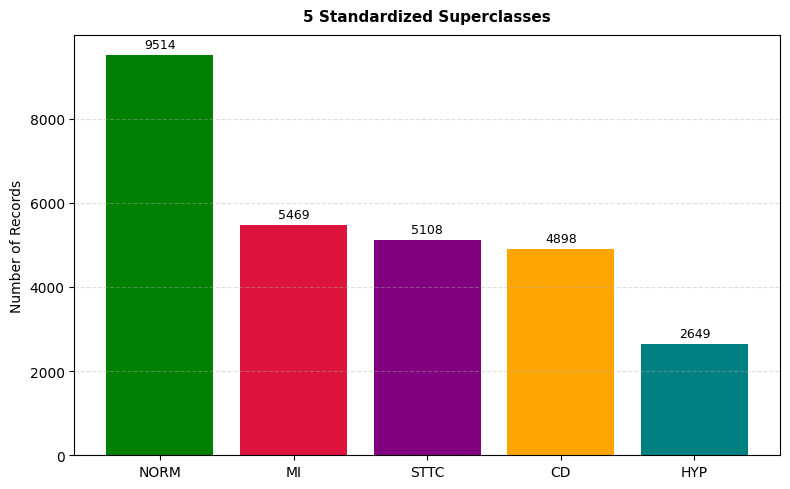

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

superclass_counts = df[target_cols].sum()

colors = ['green', 'crimson', 'purple', 'orange', 'teal']
bars = ax.bar(superclass_counts.index, superclass_counts.values, color=colors)

ax.set_title('5 Standardized Superclasses', fontsize=11, fontweight='bold', pad=10)
ax.set_ylabel('Number of Records')
ax.bar_label(bars, fmt='%d', padding=3, fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [7]:
keep_cols = [
    'patient_id', 'age', 'sex', 'height', 'weight', 'strat_fold',
    'filename_lr', 'filename_hr', 'scp_codes', 'superclasses',
    'NORM', 'MI', 'STTC', 'CD', 'HYP'
]

df_clean = df[[col for col in keep_cols if col in df.columns]]

In [8]:
final_data = '/content/drive/MyDrive/FundamentofDS/processed/multi'
output_path = os.path.join(final_data, 'ptbxl_labeled (multi).csv')
df_clean.to_csv(output_path)